(01-02-bachelier)=

# Regnault, Bachelier en de random walk

```{admonition} Waar we zijn in het verhaal
:class: important

**Jaartal.** 1863–1959.

**Wat we al weten.** [](#00-01-rendementen) leidde de $\sqrt{t}$-regel af uit
de aanname dat rendementen onafhankelijk zijn. Het liet ook zien dat het
gemiddelde rendement slecht meetbaar is en de variantie goed. Deze lecture
draait de volgorde om: de regel werd in 1863 gemeten, 37 jaar voordat Bachelier
er een model voor gaf.

**Welke vraag staat open.** Als de gemiddelde koersafwijking met $\sqrt{t}$
groeit, welk model van de prijs past daarbij, en hoe toetst men dat model?
```

## Overzicht

Hoe beweegt een koers als niemand de volgende stap kan voorspellen? Als een
*random walk* (een som van ongecorreleerde schokken): de spreiding groeit met de
wortel van de tijd, en een optie is te prijzen uit die spreiding alleen. Over
het niveau van de koers zegt het model niets. In deze lecture:

- tellen we in een wandeling van vier stappen na dat de variantie lineair groeit
  en de spreiding met de wortel van het aantal stappen,

- leiden we af dat een random walk in de limiet een Brownse beweging wordt, met
  twee gevolgen: de kans om een niveau te raken en Bacheliers optieprijs,

- schrijven we de $\sqrt{t}$-wet op als toets, de variance ratio,

- simuleren we hoeveel jaren data nodig zijn om een kleine autocorrelatie te zien,

- repliceren we Regnaults wet op Shillers maandreeks vanaf 1871, en de
  autocorrelaties en variance ratios van Kendall en van Lo en MacKinlay
  {cite}`LoMacKinlay1988` op French-data.

In 1863 schreef Jules Regnault, beambte aan de Parijse beurs, dat de gemiddelde
absolute afwijking van de koers evenredig is met de wortel van de verstreken tijd
{cite}`Regnault1863`. Louis Bachelier maakte er in 1900 een model van: de
Brownse beweging als limiet van een random walk {cite}`Bachelier1900`. Hij
leidde er de eerste optieformule mee af, vijf jaar voordat Einstein dezelfde
wiskunde voor zwevende deeltjes gebruikte. Zonder Bachelier was Regnaults regel een meting gebleven. Bachelier gaf als
enige een model waaruit ze volgt. Zijn proefschrift
bleef een halve eeuw ongelezen, ook omdat de kansrekening pas in 1933 een
formele taal voor stochastische processen kreeg. Daarna kwamen de empirici.
Cowles liet zien dat beroepsvoorspellers de markt niet versloegen
{cite}`Cowles1933`, Working stelde de random walk voor als nulhypothese
{cite}`Working1934`, en Kendall vond in wekelijkse prijsreeksen een samenhang
die te zwak was om mee te voorspellen {cite}`Kendall1953`.

Bij elk model in deze reeks stellen we de vraag *theorie of feit*: is dit een
theorie die getoetst wordt, of een feit dat op een verklaring wacht? De random
walk is een feit met een statistisch model, maar zonder economische verklaring.
Waarom goed werkende markten zulke prijzen moeten opleveren, bewees Samuelson pas
in 1965 {cite}`Samuelson1965`.

## Intuïtie: waarom zou dit waar zijn?

Denk aan iemand die elke dag een munt opgooit. Bij kop zet hij een stap naar
rechts, bij munt een stap naar links. Na honderd dagen staat hij gemiddeld op
zijn beginpunt, want de stappen heffen elkaar op. Toch staat hij er vrijwel
zeker niet. Hoe ver is hij er doorgaans vandaan?

De afstand kan niet evenredig met het aantal dagen groeien, want dan liep hij
altijd dezelfde kant op. Hij kan ook niet gelijk blijven, want dan kwam hij
nooit ver. Zijn de stappen onafhankelijk, dan tellen hun varianties op, en groeit
de afstand met de wortel van de tijd. Twee keer zo lang wachten geeft 1,41 keer
zo veel spreiding, vier keer zo lang wachten het dubbele.

Meer zegt Regnaults wet niet. Hij drukte haar in hoofdletters af: de gemiddelde
absolute afwijking van de koers is evenredig met de wortel van de tijd.

> l'écart des cours est en raison directe de la racine carrée des temps

Regnault schreef over de Franse 3%-rente, maar het mechanisme is dat van de
muntworp: een koersverandering vandaag zegt niets over die van morgen. Het
economische argument kwam later. Wist iedereen dat de koers morgen stijgt, dan
wilde vandaag niemand verkopen, en steeg de koers vandaag al.

Bachelier maakte de schokken oneindig klein en oneindig frequent. Daaruit
ontstaat de Brownse beweging, waarmee meer uit te rekenen valt dan de spreiding.
Wat verwachten we dus?

- De spreiding en de gemiddelde absolute afwijking van koersveranderingen groeien
  met de wortel van de horizon.

- Een optie *op het geld* (uitoefenprijs gelijk aan de huidige koers) betaalt
  alleen bij uitschieters naar boven. Haar
  waarde is dus evenredig met de spreiding van de koers op de vervaldag: een vier
  keer zo lange looptijd kost het dubbele. De evenredigheidsfactor, ongeveer 0,4,
  leidt de theorie af.

- Elke autocorrelatie van koersveranderingen is nul.

## Toy-voorbeeld: een random walk van vier stappen

De $\sqrt{t}$-wet is al zichtbaar in een wandeling van vier stappen. De cel
hieronder laadt de pakketten. Het is de enige cel met imports.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product
from scipy import stats

import hap
from hap import data as hap_data
hap.plotting.setup()

rng = np.random.default_rng(20240101)

**Opzet.** Op elk tijdstip $k = 1, \dots, 4$ zet de wandelaar een stap
$\varepsilon_k$ van $+1$ of $-1$, elk met kans $\tfrac12$, onafhankelijk van de
andere. Zijn positie is $S_n = \varepsilon_1 + \dots + \varepsilon_n$, met
$S_0 = 0$. Er zijn $2^4 = 16$ even waarschijnlijke paden.

| $S_4$ | $-4$ | $-2$ | $0$ | $2$ | $4$ |
|---|---|---|---|---|---|
| aantal paden | 1 | 4 | 6 | 4 | 1 |
| kans | $1/16$ | $4/16$ | $6/16$ | $4/16$ | $1/16$ |

**Stap 1: de variantie.** De verwachting is nul, want de verdeling is
symmetrisch. De variantie is het kansgewogen kwadraat van de eindpositie:

$$
\Var(S_4) = \frac{16 \cdot 1 + 4 \cdot 4 + 0 \cdot 6 + 4 \cdot 4 + 16 \cdot 1}{16}
          = \frac{64}{16} = 4 .
$$

**Stap 2: de regel achter het getal.** Elke stap heeft variantie 1 en de stappen
zijn ongecorreleerd, dus $\Var(S_n) = n$ en de standaarddeviatie is $\sqrt{n}$.
Dat is Regnaults wet zonder limiet en zonder normale verdeling.

**Stap 3: de gemiddelde absolute afwijking.** Regnault mat niet de
standaarddeviatie maar de *écart*, de gemiddelde absolute afwijking $\E|S_n|$.
In deze lecture heet $\E|\cdot|$ steeds zo, en "spreiding" is de standaarddeviatie.

$$
\E|S_4| = \frac{4 \cdot 1 + 2 \cdot 4 + 0 \cdot 6 + 2 \cdot 4 + 4 \cdot 1}{16}
        = \frac{24}{16} = 1{,}50 .
$$

Na één stap is $\E|S_1| = 1$. Na twee stappen staat de wandelaar op $-2$, $0$ of
$2$ met kansen $\tfrac14$, $\tfrac12$, $\tfrac14$, dus $\E|S_2| = 1$: de helft
van de paden keert terug naar nul. Na drie stappen is
$\E|S_3| = (6 \cdot 1 + 2 \cdot 3)/8 = 1{,}50$.

**Stap 4: de verhouding tot de wortel.** $\E|S_n|/\sqrt{n}$ loopt van $1{,}000$
via $0{,}707$ en $0{,}866$ naar $0{,}750$. Ze schommelt, want de wandeling is nog
grof.

**Het recept.** Voor lange wandelingen nadert die verhouding
$\sqrt{2/\pi} \approx 0{,}798$. De theorie leidt dat als eerste af. De variantie
volgt $n$ meteen, de absolute afwijking volgt $\sqrt{n}$ pas op den duur.

De code telt alle zestien paden na en zet de getallen met de hand ernaast.

In [2]:
paths = np.array(list(product([-1, 1], repeat=4)))   # 16 paden van 4 stappen
positions = paths.cumsum(axis=1)                     # kolom n-1 bevat S_n
final = positions[:, -1]                             # eindpositie S_4

n = np.arange(1, 5)
var_by_code = positions.var(axis=0)
mean_abs_by_code = np.abs(positions).mean(axis=0)

toy = pd.DataFrame(
    {
        "Var(S_n) met de hand": [1, 2, 3, 4],
        "Var(S_n) code": var_by_code,
        "E|S_n| met de hand": [1.0, 1.0, 1.5, 1.5],
        "E|S_n| code": mean_abs_by_code,
        "E|S_n| / sqrt(n) met de hand": [1.0, 0.7071, 0.8660, 0.75],
        "E|S_n| / sqrt(n) code": mean_abs_by_code / np.sqrt(n),
    },
    index=pd.Index(n, name="n"),
)
toy.round(4)

,Var(S_n) met de hand,Var(S_n) code,E|S_n| met de hand,E|S_n| code,E|S_n| / sqrt(n) met de hand,E|S_n| / sqrt(n) code
n,,,,,,
1,1,1.0,1.0,1.0,1.0000,1.0000
2,2,2.0,1.0,1.0,0.7071,0.7071
3,3,3.0,1.5,1.5,0.8660,0.8660
4,4,4.0,1.5,1.5,0.7500,0.7500


De kolommen met de hand en code zijn gelijk. We weten nu dat de variantie van
een som van ongecorreleerde stappen lineair groeit, en de spreiding dus met de
wortel van het aantal stappen.

## Theorie

We leiden vier dingen af. Eerst de kern: een random walk wordt in de limiet een
Brownse beweging, waarvan de gemiddelde absolute afwijking met de wortel van de
horizon groeit, met de factor $\sqrt{2/\pi}$ uit het toy-voorbeeld. Daarna twee
gevolgen: de kans om een niveau te raken en Bacheliers optieprijs. Ten slotte de
variance ratio, de toets waar simulatie en replicatie om draaien. De replicatie
toetst twee resultaten: de $\sqrt{t}$-wet en een variance ratio van één. De
raakkans en de optieprijs toetsen we niet op data.

### Opzet en aannames

De nulhypothese is de random walk in log-prijzen. *Vanaf hier zijn kleine
letters logs*: $p_t = \log P_t$, met $P_t$ de prijs, en
$r_{t+1} = p_{t+1} - p_t$ het log-rendement. Onder de nulhypothese zijn de
$r_{t+1}$ onderling ongecorreleerd, met verwachting $\mu$ en variantie
$\sigma^2$. Voor Amerikaanse maandrendementen is $\mu$ ongeveer 1% en $\sigma$
ongeveer 5%. De toetsen gebruiken alleen varianties en autocorrelaties, dus
$\mu$ speelt verder geen rol. In de notatie van [](#00-00-setup) is $r$ het
simpele rendement. In deze lecture is het dus een logrendement.

Bachelier werkte niet met logs maar met het prijsniveau $P_t$. Zijn proces heet
nu *aritmetische Brownse beweging*: de absolute prijsveranderingen zijn normaal
verdeeld. Zijn volatiliteit noemen we $v$, een bedrag in euro per
$\sqrt{\text{jaar}}$: bij een aandeel van 100 met 20% volatiliteit ongeveer 20
euro. Drie symbolen houden in deze lecture één betekenis: $\sigma$ is de
standaarddeviatie van één stap of één rendement, $S_n$ de positie van een
wandeling, en $T$ het aantal waarnemingen. In [](#00-01-rendementen) heette dat
laatste $N$ en was $T$ het aantal jaren.

### Het kernresultaat: van random walk naar Brownse beweging

Worden de stappen kleiner en talrijker, dan wordt de wandeling een Brownse
beweging, welke verdeling de stappen ook hebben.

*Waarom zou dit waar zijn?* Een belegger houdt een aandeel een maand vast. Zijn
maandrendement is de som van twintig dagrendementen. Zijn die onafhankelijk, dan
middelen de uitschieters van losse dagen weg, en wordt het maandrendement bij
benadering normaal verdeeld. Clusterende volatiliteit vertraagt dat, zoals de
replicatie laat zien. Houdt hij langer vast, dan stijgt de spreiding van zijn
resultaat met de wortel van de looptijd, want de varianties tellen op.

We herschalen de wandeling in de ruimte met $\sqrt{n}$ en in de tijd met $n$,
met $\sigma$ de standaarddeviatie van één stap. Het doel is een *standaard
Brownse beweging* $W$: een continu proces met $W_0 = 0$ en onafhankelijke
aangroeiingen $W_{t+h} - W_t \sim \mathcal{N}(0, h)$.

```{math}
:label: eq-bachelier-donsker
W^{(n)}(u) \;=\; \frac{1}{\sigma\sqrt{n}}\,S_{\lfloor n u \rfloor},
\qquad u \in [0,1].
```

In woorden: $W^{(n)}(u)$ is de positie na een fractie $u$ van de $n$ stappen,
gemeten in standaarddeviaties van de hele wandeling.

:::{prf:theorem} Invariantieprincipe (Donsker)
:label: thm-bachelier-donsker

Laat $\varepsilon_1, \varepsilon_2, \dots$ onafhankelijk en identiek verdeeld
zijn met $\E[\varepsilon] = 0$ en $\Var(\varepsilon) = \sigma^2 < \infty$, en
$S_n = \sum_{k \le n}\varepsilon_k$. Dan convergeert het proces
$W^{(n)}$ uit [](#eq-bachelier-donsker) in verdeling naar de standaard Brownse
beweging $W$ op $[0,1]$.
:::

In woorden: bij veel kleine stappen is de herschaalde wandeling niet van een
Brownse beweging te onderscheiden. De stelling vraagt meer dan de nulhypothese:
onafhankelijke stappen met verwachting nul. Daarom trekt de replicatie eerst het
gemiddelde af. Het gaat om de verdeling van het hele pad, niet alleen van de
eindpositie. Zo convergeert ook het maximum van het pad, en dat gebruikt de
raakkans hieronder. Donsker bewees dit in 1951. De schets toont alleen de
verdeling op vaste tijdstippen.

:::{prf:proof}
:class: dropdown

*Schets: de eindig-dimensionale verdelingen.* Voor één tijdstip $u$ geldt

$$
W^{(n)}(u) = \frac{1}{\sigma\sqrt{n}} \sum_{k \le \lfloor nu\rfloor} \varepsilon_k
= \sqrt{\frac{\lfloor nu \rfloor}{n}} \cdot
  \frac{1}{\sigma\sqrt{\lfloor nu\rfloor}}\sum_{k \le \lfloor nu\rfloor}\varepsilon_k
\;\Rightarrow\; \sqrt{u}\cdot Z, \qquad Z \sim \mathcal{N}(0,1),
$$

door de centrale limietstelling, en dus $W^{(n)}(u) \Rightarrow \mathcal{N}(0,u)$.
Voor twee tijdstippen $u < u'$ zijn $W^{(n)}(u)$ en $W^{(n)}(u') - W^{(n)}(u)$ sommen
over disjuncte blokken en dus onafhankelijk. In de limiet is dat de definiërende
eigenschap van de Brownse beweging: onafhankelijke, normaal verdeelde
aangroeiingen met $\Var(W_{u'} - W_u) = u' - u$. $\square$
:::

Daarmee is Regnaults wet een stelling geworden in plaats van een meting:

$$
\SD(W_{t+h} - W_t) = \sqrt{h}, \qquad \E|W_{t+h} - W_t| = \sqrt{2h/\pi}.
$$

De tweede formule volgt uit de eerste: $W_{t+h} - W_t = \sqrt{h}\,Z$ met $Z$
standaardnormaal, en $\E|Z| = 2\int_0^\infty z\,\varphi(z)\,\mathrm{d}z =
2\varphi(0) = \sqrt{2/\pi}$, met $\varphi$ de standaardnormale dichtheid. Zoals de
intuïtie voorspelde, groeit de gemiddelde absolute afwijking met de wortel van de horizon. Bij $h = 4$ geeft de tweede formule $\sqrt{8/\pi} \approx 1{,}60$, tegen $1{,}50$
in het toy-voorbeeld: vier stappen zitten nog 6% onder de limiet.

De figuur hieronder toont veertig herschaalde wandelingen van 2000 stappen. Let
op de bundel, niet op één pad.

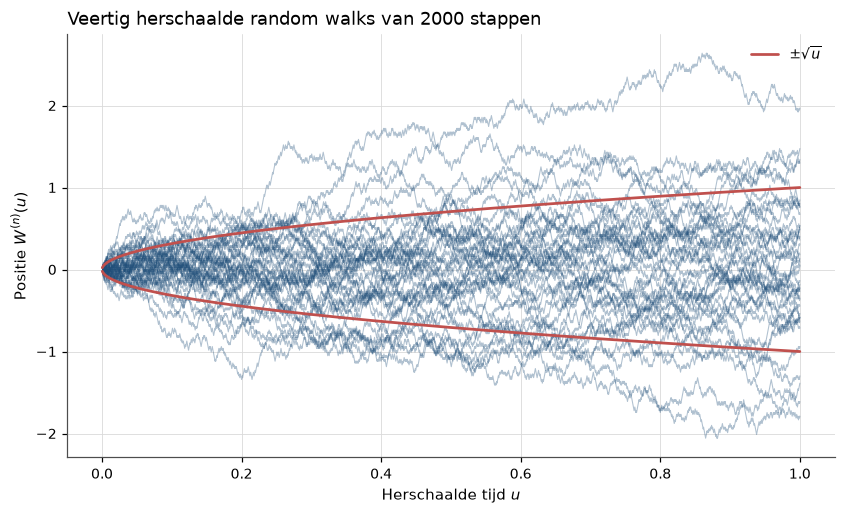

In [3]:
n_steps, n_shown = 2000, 40
steps = rng.choice([-1.0, 1.0], size=(n_shown, n_steps)) / np.sqrt(n_steps)
walks = steps.cumsum(axis=1)
grid = np.arange(1, n_steps + 1) / n_steps

fig, ax = plt.subplots()
ax.plot(grid, walks.T, lw=0.7, color=hap.plotting.COLORS[0], alpha=0.35)
for sign in (-1, 1):
    ax.plot(grid, sign * np.sqrt(grid), color=hap.plotting.COLORS[1], lw=1.8,
            label=r"$\pm\sqrt{u}$" if sign == 1 else None)
ax.set_title("Veertig herschaalde random walks van 2000 stappen")
ax.set_xlabel("Herschaalde tijd $u$")
ax.set_ylabel("Positie $W^{(n)}(u)$")
ax.legend()
plt.show()

:::{figure} #cel-bachelier-paden
:label: fig-bachelier-paden
:width: 90%

Veertig paden van een symmetrische random walk, herschaald volgens
[](#eq-bachelier-donsker). Geen enkel pad is glad, maar de bundel heeft een
scherpe omhullende: de rode krommen zijn $\pm\sqrt{u}$, één standaarddeviatie.
Wie naar één pad kijkt, ziet patronen. Wie naar de bundel kijkt, ziet
$\sqrt{t}$.
:::

### Wat het voorspelt: de kans om een niveau te raken

De kans dat de koers vóór een datum ooit een niveau $a$ raakt, is ongeveer twee
keer de kans dat hij op die datum boven $a$ staat.

De raakkans gebruikt de verdeling van het hele pad, niet alleen die van de
eindpositie. Daarvoor was de stelling van Donsker nodig.

*Waarom zou dit waar zijn?* Een belegger legt een verkooporder neer op een
niveau $a$ boven de koers. Na de eerste aanraking is een stap omhoog even
waarschijnlijk als een stap omlaag. Voor elk pad dat daarna terugzakt, is er dus
een even waarschijnlijk pad dat boven $a$ eindigt: de order wordt twee keer zo
vaak uitgevoerd als de eindkoers doet vermoeden.

:::{prf:theorem} Reflectieprincipe
:label: thm-bachelier-reflectie

Laat $S_n$ een symmetrische random walk zijn met stappen $\pm 1$ en
$M_n = \max_{k \le n} S_k$. Voor $a \ge 1$ geldt

```{math}
:label: eq-bachelier-reflectie
P(M_n \ge a) \;=\; P(S_n = a) \,+\, 2\,P(S_n > a).
```
:::

In woorden: de kans om $a$ ooit te raken is de kans om er precies op te eindigen,
plus twee keer de kans om erboven te eindigen. Een hoger niveau maakt de
raakkans kleiner, een langere horizon maakt haar groter. Bewijsidee: spiegel elk pad dat $a$ raakt en daarna onder $a$ eindigt, vanaf
de eerste aanraking, in het niveau $a$. Zo ontstaat een even waarschijnlijk pad
dat boven $a$ eindigt, en elk pad boven $a$ ontstaat zo precies één keer.

In de Brownse limiet is de kans om exact op $a$ te eindigen nul, en blijft
$P(\max_{s \le h} W_s \ge a) = 2\,P(W_h \ge a)$ over. Een voorbeeld, zonder
drift: een verkooporder 10 euro boven de koers, bij een volatiliteit $v$ van 20
euro per $\sqrt{\text{jaar}}$. De order ligt dan een halve standaarddeviatie
boven de koers. Na een jaar eindigt de koers in $1 - \Phi(0{,}5) \approx 31\%$
van de gevallen boven de order, en de order wordt in 62% van de gevallen
uitgevoerd.

In het toy-voorbeeld is $n = 4$ en $a = 2$. De stelling geeft
$P(S_4 = 2) + 2P(S_4 > 2) = 4/16 + 2 \cdot 1/16 = 0{,}375$. De code telt dat na
op de zestien paden.

In [4]:
touches_two = positions.max(axis=1) >= 2             # raakt het pad ooit +2?
by_counting = touches_two.mean()
by_reflection = (np.sum(final == 2) + 2 * np.sum(final > 2)) / 16

pd.Series(
    {"met de hand": 0.375, "geteld over 16 paden": by_counting,
     "reflectieprincipe": by_reflection},
    name="P(max S_k >= 2)",
).round(4)

met de hand             0.375
geteld over 16 paden    0.375
reflectieprincipe       0.375
Name: P(max S_k >= 2), dtype: float64

Tellen en spiegelen geven allebei $0{,}375$.

### Wat het voorspelt: Bacheliers optieprijs

Volgt de koers een aritmetische Brownse beweging, dan is een calloptie haar
verwachte uitbetaling waard. Op het geld is dat ongeveer $0{,}4\,v\sqrt{\tau}$.

*Waarom zou dit waar zijn?* Bachelier nam aan dat de speculant gemiddeld niets
wint (*l'espérance mathématique du spéculateur est nulle*). Wij noemen dat de
*martingaalconditie*: de verwachte koers op de vervaldag is de koers van
vandaag, $\E_t[P_{t+\tau}] = P_t$, zoals in een eerlijk kansspel. Een koper die meer
betaalt dan de verwachte uitbetaling, verliest dan gemiddeld, en een verkoper
die minder vraagt ook. De optieprijs is dus de verwachte uitbetaling. Hoe breder
de verdeling van de koers op de vervaldag, hoe meer de optie waard is: ze
verdient aan uitschieters naar boven en verliest niets aan die naar beneden.

:::{prf:theorem} Bacheliers optieprijs
:label: thm-bachelier-optie

Zij $P_{t+\tau} = P_t + v (W_{t+\tau} - W_t)$ met $W$ een standaard Brownse beweging, dus
$P_{t+\tau} \mid \mathcal{F}_t \sim \mathcal{N}\!\left(P_t, v^2 \tau\right)$ met
$\mathcal{F}_t$ de informatie op $t$ en $\tau$ de looptijd. Onder de
martingaalconditie is de waarde van een calloptie met uitoefenprijs $K$, bij een
rente van nul,

```{math}
:label: eq-bachelier-call
C_t \;=\; (P_t - K)\,\Phi(d) \;+\; v\sqrt{\tau}\,\varphi(d),
\qquad d \;=\; \frac{P_t - K}{v\sqrt{\tau}},
```

met $\Phi$ en $\varphi$ de verdelings- en dichtheidsfunctie van de
standaardnormale verdeling.
:::

In woorden: de optie is de intrinsieke waarde $P_t - K$ waard, gewogen met
$\Phi(d)$, de kans dat de optie in het geld eindigt, plus een term die groeit met de spreiding
$v\sqrt{\tau}$ van de koers op de vervaldag. Diep *in het geld* (uitoefenprijs
ver onder de koers) nadert de waarde $P_t - K$, ver *uit het geld* nadert ze nul.
Het bewijs integreert de uitbetaling over de normale dichtheid.

:::{prf:proof}
:class: dropdown

Schrijf $s = v\sqrt{\tau}$ en $x = P_t - K$. Onder de martingaalconditie is
$P_{t+\tau} = P_t + sZ$ met $Z \sim \mathcal{N}(0,1)$, dus

$$
C_t = \E\!\left[(P_{t+\tau} - K)^{+}\right]
 = \int_{-x/s}^{\infty} (x + sz)\,\varphi(z)\,\mathrm{d}z .
$$

De eerste term is $x\left[1 - \Phi(-x/s)\right] = x\,\Phi(x/s)$. Voor de tweede
gebruiken we $z\varphi(z) = -\varphi'(z)$:

$$
s\int_{-x/s}^{\infty} z\,\varphi(z)\,\mathrm{d}z
= s\Bigl[-\varphi(z)\Bigr]_{-x/s}^{\infty} = s\,\varphi(-x/s) = s\,\varphi(x/s),
$$

want $\varphi$ is even. Samen geeft dit [](#eq-bachelier-call). $\square$
:::

Voor een optie *op het geld* ($K = P_t$, dus $d = 0$) blijft alleen de tweede
term over:

```{math}
:label: eq-bachelier-atm
C_t \;=\; \frac{v\sqrt{\tau}}{\sqrt{2\pi}} \;\approx\; 0{,}3989\,v\sqrt{\tau}.
```

In woorden: de optie is vier tiende van de spreiding van de koers op de
vervaldag waard. Bij $v = 20$ euro en een looptijd van een jaar is dat 7,98
euro. Zoals de intuïtie voorspelde, is de prijs evenredig met $\sqrt{\tau}$: wie
de looptijd verviervoudigt, betaalt het dubbele. Er staat geen risicoaversie en
geen verwacht rendement in. Dat is hier een gevolg van de aangenomen
martingaalconditie. Black en Scholes lieten later zien waarom ze mag: een optie die met aandeel en
kas na te maken is, kost wat die portefeuille kost, welk verwacht rendement men
ook aanneemt. Er wordt
niet verdisconteerd, omdat Bachelier met termijnkoersen werkte: een prijs die nu
wordt afgesproken en later betaald.

Black en Scholes {cite}`BlackScholes1973` lieten de *relatieve* prijsverandering
normaal verdeeld zijn in plaats van de absolute. Daarover gaat
[](#02-09-black-scholes). Bij korte looptijden en rond het geld vallen de twee
prijzen vrijwel samen, met $v \approx \sigma_{\text{BS}} \cdot P_t$.
De cel rekent beide uit voor een aandeel van 100 met een Black-Scholes-volatiliteit
van 20% per jaar, voor drie looptijden en drie uitoefenprijzen.

In [5]:
def bachelier_call(S, K, sigma_abs, tau):
    """Bachelier (1900) call price under arithmetic Brownian motion, zero rate."""
    s = sigma_abs * np.sqrt(tau)
    d = (S - K) / s
    return (S - K) * stats.norm.cdf(d) + s * stats.norm.pdf(d)


def bs_call(S, K, sigma, tau):
    """Black-Scholes (1973) call price, zero rate."""
    d1 = (np.log(S / K) + 0.5 * sigma**2 * tau) / (sigma * np.sqrt(tau))
    d2 = d1 - sigma * np.sqrt(tau)
    return S * stats.norm.cdf(d1) - K * stats.norm.cdf(d2)


S0, sigma_bs = 100.0, 0.20
rows = []
for tau in (1 / 12, 0.5, 1.0):
    for K in (90.0, 100.0, 110.0):
        rows.append(
            {
                "looptijd (jaar)": tau,
                "K": K,
                "Bachelier": bachelier_call(S0, K, sigma_bs * S0, tau),
                "Black-Scholes": bs_call(S0, K, sigma_bs, tau),
            }
        )
table = pd.DataFrame(rows)
table["verschil"] = table["Bachelier"] - table["Black-Scholes"]
table.round(4)

,looptijd (jaar),K,Bachelier,Black-Scholes,verschil
0,0.0833,90.0,10.0976,10.0734,0.0242
1,0.0833,100.0,2.3033,2.3030,0.0003
2,0.0833,110.0,0.0976,0.1247,-0.0271
3,0.5000,90.0,11.9964,11.7725,0.2240
4,0.5000,100.0,5.6419,5.6372,0.0047
5,0.5000,110.0,1.9964,2.2112,-0.2148
6,1.0000,90.0,13.9559,13.5891,0.3668
7,1.0000,100.0,7.9788,7.9656,0.0133
8,1.0000,110.0,3.9559,4.2920,-0.3361


Bij een looptijd van een maand verschillen de twee prijzen hooguit drie cent.
Bij een jaar en tien procent uit het geld is het verschil 0,34 euro, op een
optie van ongeveer vier euro. Op het geld geeft de tabel bij een jaar 7,98, zoals
[](#eq-bachelier-atm) voorspelde. Dat de Bachelier-koers negatief kan worden, is
voor een aandeel onzin. Voor een termijncontract is het juist gewenst: toen de
termijnprijs van ruwe olie in april 2020 negatief werd, kwam de formule weer in
gebruik.

De optieformule zelf toetsen we hier niet, want historische optieprijzen zijn
niet gratis. Wel toetsen we de aanname eronder: koersveranderingen zijn
onvoorspelbaar.

### Hoe het getoetst wordt: de variance ratio

De hoofdtoets is de variance ratio. Ze bundelt veel kleine autocorrelaties en
gebruikt alleen varianties, die goed meetbaar zijn. Net als de autocorrelatie
kijkt ze naar koersveranderingen, niet naar het niveau. De slotkoers van morgen
is met een kleine fout te voorspellen: het is ongeveer de koers van vandaag. De koers*verandering* van morgen is dat niet.

**Autocorrelatie.** Onder de nulhypothese is $\rho_k = \Corr(r_t, r_{t-k}) = 0$
voor elke $k \ge 1$. De steekproefautocorrelatie heeft dan bij benadering
standaardfout $1/\sqrt{T}$, met $T$ het aantal waarnemingen: $0{,}029$ bij een
eeuw maanddata. Kendall rekende deze grootheid uit.

**Variance ratio.** De tweede toets is de $\sqrt{t}$-wet in één getal:

```{math}
:label: eq-bachelier-vr
VR(q) \;=\; \frac{\Var\!\left(r_t + r_{t-1} + \dots + r_{t-q+1}\right)}
                  {q\,\Var(r_t)} .
```

In woorden: de variantie van een rendement over $q$ perioden, gedeeld door $q$
keer de variantie over één periode. Onder de random walk is $VR(q) = 1$ voor
elke $q$, want de variantie groeit lineair, zoals in het toy-voorbeeld. Boven één
wijst op positieve autocorrelatie, onder één op negatieve.

:::{prf:theorem} Variance ratio als gewogen som van autocorrelaties
:label: thm-bachelier-vr

Voor een covariantie-stationaire reeks (gemiddelde, variantie en
autocovarianties veranderen niet in de tijd, zoals bij het proces
$r_t = \rho\, r_{t-1} + e_t$ met $|\rho| < 1$) geldt

```{math}
:label: eq-bachelier-vr-rho
VR(q) \;=\; 1 + 2\sum_{j=1}^{q-1}\left(1 - \frac{j}{q}\right)\rho_j .
```
:::

In woorden: $VR(q)$ is één plus een gewogen som van de eerste $q - 1$
autocorrelaties, met lineair aflopende gewichten. Is alleen $\rho_1 = 0{,}1$, dan
is $VR(4) = 1 + 2 \cdot \tfrac34 \cdot 0{,}1 = 1{,}15$. Voor $q = 2$ volgt
$VR(2) - 1 = \rho_1$, exact.

:::{prf:proof}
:class: dropdown

Schrijf $\gamma_j = \Cov(r_t, r_{t-j})$, dus $\rho_j = \gamma_j/\gamma_0$. De
variantie van de som van $q$ opeenvolgende termen telt $q$ keer $\gamma_0$, en
voor elke $j \ge 1$ telt ze $2(q-j)$ keer $\gamma_j$: er zijn $q - j$ paren op
afstand $j$ en elk paar telt twee keer mee.

$$
\Var\Bigl(\sum_{i=0}^{q-1} r_{t-i}\Bigr)
 = q\gamma_0 + 2\sum_{j=1}^{q-1}(q-j)\gamma_j .
$$

Delen door $q\gamma_0$ geeft [](#eq-bachelier-vr-rho). $\square$
:::

De variance ratio is om twee redenen de hoofdtoets. Ze bundelt: is de
afhankelijkheid over veel vertragingen uitgesmeerd, dan verdwijnt elke $\rho_j$
apart in de ruis, maar hun gewogen som niet. En ze gebruikt alleen varianties.
Dat is de standaardfout van 2% uit [](#00-01-rendementen) van de andere kant.
Het gemiddelde jaarrendement is na een eeuw data nog maar op twee procentpunt
nauwkeurig, maar een variantie is over dezelfde eeuw veel nauwkeuriger bekend.
Een toets die alleen varianties vergelijkt, heeft daardoor scherpte.

Onder de nulhypothese en bij constante variantie is de standaardfout van
$VR(q)$ gelijk aan $\sqrt{2(2q-1)(q-1)/(3qT)}$ {cite}`LoMacKinlay1988`. Voor
$q = 2$ is dat $1/\sqrt{T}$. Bij de 1216 weken van Lo en MacKinlay is ze
$0{,}029$, $0{,}054$, $0{,}085$ en $0{,}126$ voor $q = 2, 4, 8, 16$: bij lange
horizonnen is de toets minder scherp. De functie `hap.variance_ratio` geeft
$VR(q)$ (sleutel `vr`) en de toetsgrootheid $z_2$ (sleutel `z2`), die robuust is
voor clusterende volatiliteit: rustige en woelige perioden wisselen elkaar af,
en de gewone $z$ zou de ruis dan onderschatten. Lo en MacKinlay noemen haar $z^{*}$.

```{admonition} Samengevat
:class: tip

- Een random walk wordt in de limiet een Brownse beweging, met
  $\E|W_{t+h} - W_t| = \sqrt{2h/\pi}$: Regnaults wet als stelling,
  [](#thm-bachelier-donsker).

- De kans om een niveau te raken is $P(S_n = a) + 2P(S_n > a)$,
  [](#eq-bachelier-reflectie), in de Brownse limiet exact twee keer de kans om
  erboven te eindigen. Een hoger niveau maakt haar kleiner, een langere horizon
  groter.

- Een optie op het geld is $0{,}4\,v\sqrt{\tau}$ waard,
  [](#eq-bachelier-atm): hoger bij meer volatiliteit of een langere looptijd,
  zonder verwacht rendement of risicoaversie.

- $VR(q) - 1$ is een gewogen som van autocorrelaties, [](#eq-bachelier-vr-rho):
  positief bij positieve autocorrelatie, negatief bij negatieve. Een grotere $q$
  telt meer vertragingen mee, maar met een grotere standaardfout.

- De simulatie hierna vraagt: hoeveel jaren weekdata zijn nodig om een kleine
  autocorrelatie met $VR(2)$ te zien?
```

## Simulatie: hoeveel data om een afwijking te zien?

Een kleine autocorrelatie is pas na tientallen jaren data te zien. We bouwen een wereld van weekrendementen met 2% volatiliteit per
week, eerst zonder afhankelijkheid en daarna met eerste autocorrelatie $\rho$.
Als maat nemen we de steekproef van Lo en MacKinlay: $T = 1216$ weken, ruim
drieëntwintig jaar. De eerste cel trekt 2000 paden zonder afhankelijkheid en
vergelijkt de spreiding van $\widehat{VR}(2)$ met $1/\sqrt{T}$.

In [6]:
n_paths, T_lm = 2000, 1216
iid_paths = rng.normal(0.0, 0.02, size=(n_paths, T_lm))
vr_null = np.array([hap.variance_ratio(pd.Series(p), 2)["vr"] for p in iid_paths])

pd.DataFrame(
    {
        "waarde": [
            vr_null.mean(),
            vr_null.std(ddof=1),
            1 / np.sqrt(T_lm),
            np.mean(np.abs(vr_null - 1) > 1.96 / np.sqrt(T_lm)),
        ]
    },
    index=["gemiddelde VR(2)", "std.dev. van VR(2)", "asymptotische SE",
           "verwerpingsfractie bij 5%"],
).round(4)

,waarde
gemiddelde VR(2),0.9998
std.dev. van VR(2),0.0281
asymptotische SE,0.0287
verwerpingsfractie bij 5%,0.0430


Onder de nulhypothese werkt de toets zoals bedoeld. Het gemiddelde is vrijwel
één, de spreiding van $0{,}0281$ ligt dicht bij $0{,}0287$, en de toets verwerpt
in 4,3% van de steekproeven, iets onder de nominale 5%.

Nu het alternatief: een AR(1) in log-rendementen, $r_t = \rho\, r_{t-1} + e_t$.
Daarvoor is $\rho_1 = \rho$ en dus $VR(2) = 1 + \rho$ volgens
[](#eq-bachelier-vr-rho). De cel simuleert voor drie waarden van $\rho$ en drie
steekproeflengtes elk 1000 paden en telt hoe vaak de toets verwerpt.

In [7]:
def ar1_paths(rho, n_paths, T, sigma=0.02, burn=200):
    """Simulate AR(1) log-return paths, discarding a burn-in."""
    e = rng.normal(0.0, sigma, size=(n_paths, T + burn))
    x = np.empty_like(e)
    x[:, 0] = e[:, 0]
    for t in range(1, T + burn):
        x[:, t] = rho * x[:, t - 1] + e[:, t]
    return x[:, burn:]


rows = []
for rho in (0.05, 0.10, 0.20):
    for T in (260, 1040, 4160):
        results = [hap.variance_ratio(pd.Series(p), 2) for p in ar1_paths(rho, 1000, T)]
        vr_estimates = np.array([r["vr"] for r in results])
        rejected = np.array([abs(r["z2"]) > 1.96 for r in results])
        expected_z = rho * np.sqrt(T)            # (VR(2) - 1) / SE = rho * sqrt(T)
        analytic_power = stats.norm.sf(1.96 - expected_z) + stats.norm.cdf(-1.96 - expected_z)
        rows.append({"rho": rho, "jaren weekdata": T // 52,
                     "gemiddelde VR(2)": vr_estimates.mean(),
                     "onderscheidend vermogen": rejected.mean(),
                     "analytisch": analytic_power})
power = pd.DataFrame(rows)
power.round(3)

,rho,jaren weekdata,gemiddelde VR(2),onderscheidend vermogen,analytisch
0,0.05,5,1.048,0.107,0.127
1,0.05,20,1.050,0.367,0.364
2,0.05,80,1.051,0.893,0.897
3,0.10,5,1.100,0.379,0.364
4,0.10,20,1.099,0.903,0.897
5,0.10,80,1.100,1.000,1.000
6,0.20,5,1.195,0.869,0.897
7,0.20,20,1.200,1.000,1.000
8,0.20,80,1.200,1.000,1.000


De geschatte $VR(2)$ is in alle negen gevallen vrijwel $1 + \rho$: de schatter
is nagenoeg zuiver. Het *onderscheidend vermogen*, de kans dat de toets de foute
nulhypothese verwerpt, hangt sterk af van de lengte van de steekproef. Omdat
$VR(2) - 1 = \rho$ en de standaardfout ongeveer $1/\sqrt{T}$ is, is de verwachte
$z$-waarde $\rho\sqrt{T}$. Een verwachte $z$ van 1,96 vraagt dan

```{math}
:label: eq-bachelier-power
T^{*} \;=\; \left(\frac{1{,}96}{\rho}\right)^{2}
```

waarnemingen. In woorden: halveer de autocorrelatie en de benodigde steekproef
wordt vier keer zo lang. Ook bij $T^{*}$ verwerpt de toets maar in de helft van
de steekproeven.

| $\rho$ | $T^{*}$ (weken) | jaren |
|---|---|---|
| 0,20 | 96 | 1,8 |
| 0,05 | 1537 | 30 |
| 0,02 | 9604 | 185 |

Een autocorrelatie van 0,02 vraagt 185 jaar weekdata, langer dan de 155 jaar
van Shillers maandreeks, de langste reeks in deze lecture. Vanaf twintig jaar
data volgt de simulatie de formule. Bij vijf jaar wijkt ze tot drie procentpunt
af, omdat de benadering daar nog grof is. De figuur zet het onderscheidend vermogen uit tegen de lengte van de
steekproef. Let op waar de lijnen de verticale lijn van Lo en MacKinlay kruisen.

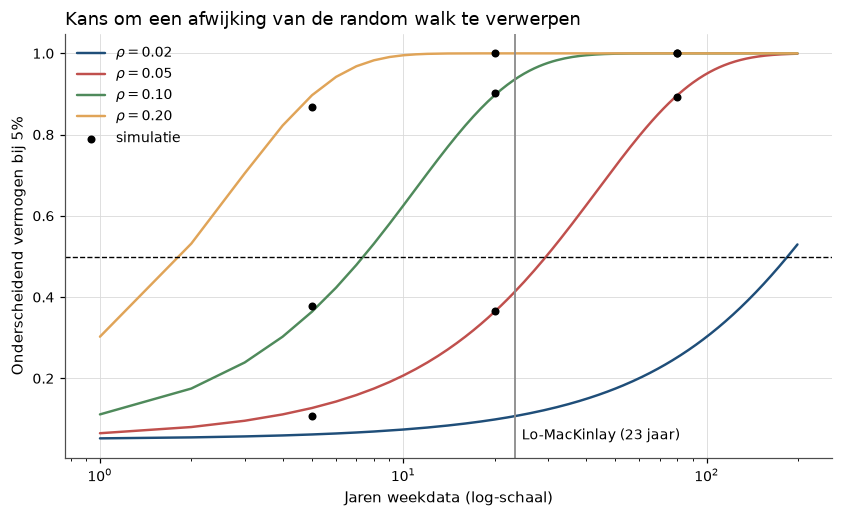

In [8]:
T_grid = np.arange(52, 10_400, 52)
lm_years = T_lm / 52                                  # 1216 weken = 23,4 jaar

fig, ax = plt.subplots()
for i, rho in enumerate((0.02, 0.05, 0.10, 0.20)):
    z = rho * np.sqrt(T_grid)
    ax.plot(T_grid / 52, stats.norm.sf(1.96 - z) + stats.norm.cdf(-1.96 - z),
            color=hap.plotting.COLORS[i], label=rf"$\rho = {rho:.2f}$")
ax.scatter(power["jaren weekdata"], power["onderscheidend vermogen"],
           color="black", s=18, zorder=3, label="simulatie")
ax.axhline(0.5, color="black", ls="--", lw=0.9)
ax.axvline(lm_years, color=hap.plotting.COLORS[7], lw=1.2)
ax.text(lm_years * 1.05, 0.05, "Lo-MacKinlay (23 jaar)", fontsize=9)
ax.set_xscale("log")
ax.set_title("Kans om een afwijking van de random walk te verwerpen")
ax.set_xlabel("Jaren weekdata (log-schaal)")
ax.set_ylabel("Onderscheidend vermogen bij 5%")
ax.legend()
plt.show()

:::{figure} #cel-bachelier-power
:label: fig-bachelier-power
:width: 90%

Het onderscheidend vermogen van de variance-ratio-toets tegen een AR(1), als
functie van de lengte van de steekproef. De zwarte punten zijn de gesimuleerde
waarden uit de tabel. Bij de drieëntwintig jaar weekdata van Lo en MacKinlay is
een autocorrelatie van 0,20 zo goed als zeker zichtbaar, en een van 0,02 zo goed
als onzichtbaar. Wie beweert dat een markt efficiënt is, zegt dus altijd: met de
data die ik heb.
:::

```{warning}
Dezelfde $T$ die te klein is om een echte $\rho$ van 0,02 te vinden, laat ruis
tot 0,06 toe: twee standaardfouten van $1/\sqrt{1216} \approx 0{,}029$. Wie
vijftig markten, tien horizonnen en drie frequenties nakijkt, vindt vrijwel
zeker ergens een $z$-waarde boven twee, zonder dat er iets te vinden is.
```

## Replicatie op echte data

```{admonition} Replicatie
:class: seealso

**Bron.** Jules Regnault, *Calcul des chances et philosophie de la bourse*,
Parijs 1863 {cite}`Regnault1863`.

**Wat.** Zijn eigen toets van de wet (§83–84): een gemiddelde absolute afwijking
van ongeveer 2,73 frank per maand, maal $\sqrt{3}$ en $\sqrt{12}$, geeft 4,73 en
9,46, tegen waargenomen ongeveer 4,74 en 9,50. Wij herhalen die vergelijking en schatten
de helling $b$ in $\log \E|p_{t+h} - p_t| = a + b \log h$ over
$h = 1, 3, 12, 60$ maanden.

**Data hier.** Shillers maandreeks van de reële S&P-prijs vanaf 1871 en de
maandelijkse marktfactor van French (het totale rendement van de waardegewogen
Amerikaanse markt) vanaf 1926.

**Verschil met het origineel.** Regnault mat de maandelijkse hoogste en laagste
koers van de Franse 3%-rente, wij een Amerikaanse aandelenindex in log-prijzen. Shillers maandprijs is een gemiddelde
van dagkoersen, en die middeling drukt de spreiding op de kortste horizon.

**Verwachte afwijking.** Helling voor French binnen 0,05 van 0,5, voor Shiller
erboven. De falsifieerbare eis: $\E|p_{t+h} - p_t|/\sqrt{h}$ blijft over de vier
horizonnen binnen een factor twee, waar een lineaire wet een factor acht
($\sqrt{60} \approx 7{,}7$) zou geven. Regnaults eigen verhouding voorspeld /
waargenomen van bijna één verwachten we niet, omdat aandelenvolatiliteit meer
wisselt dan die van zijn staatsrente.
```

De functie hieronder berekent per horizon de gemiddelde absolute afwijking en
de standaarddeviatie van de verandering in de log-prijs, na aftrek van het
gemiddelde. De kolom "Regnault" doet wat hij deed: de gemiddelde absolute
afwijking over één maand maal $\sqrt{h}$.

In [9]:
# Shiller loopt hier van 1871-01 t/m 2026-09, French vanaf 1926-07.
MAD, SD, REGNAULT = "gem. abs. afwijking", "standaarddeviatie", "Regnault: maand x sqrt(h)"


def deviation_scaling(log_level, horizons=(1, 3, 12, 60)):
    """Mean absolute and standard deviation of h-period changes, demeaned."""
    rows = []
    for h in horizons:
        dev = (log_level.shift(-h) - log_level).dropna()
        dev = dev - dev.mean()
        rows.append({"h": h, "waarnemingen": len(dev), MAD: dev.abs().mean(),
                     SD: dev.std(ddof=1)})
    out = pd.DataFrame(rows).set_index("h")
    out[REGNAULT] = out[MAD].iloc[0] * np.sqrt(out.index)
    out["gem. abs. afw. / sqrt(h)"] = out[MAD] / np.sqrt(out.index)
    out["gem. abs. afw. / SD"] = out[MAD] / out[SD]
    return out


shiller = hap_data.shiller()
p_shiller = np.log(shiller["real_price"].dropna())
p_french = np.log1p(hap_data.market_monthly()["Mkt"]).cumsum()

regnault = pd.concat(
    {"Shiller 1871-2026": deviation_scaling(p_shiller),
     "French 1926-2026": deviation_scaling(p_french)},
    names=["reeks"],
)
regnault.round(4)

waarnemingen  gem. abs. afwijking  standaarddeviatie  \
reeks             h                                                          
Shiller 1871-2026 1           1868               0.0287             0.0407   
                  3           1866               0.0595             0.0820   
                  12          1857               0.1409             0.1838   
                  60          1809               0.3026             0.3763   
French 1926-2026  1           1200               0.0373             0.0529   
                  3           1198               0.0669             0.0961   
                  12          1189               0.1460             0.1988   
                  60          1141               0.2978             0.3933   

                      Regnault: maand x sqrt(h)  gem. abs. afw. / sqrt(h)  \
reeks             h                                                         
Shiller 1871-2026 1                      0.0287                    0.0287   
                  3                      0.0497                    0.0344   
                  12                     0.0993                    0.0407   
                  60                     0.2221                    0.0391   
French 1926-2026  1                      0.0373                    0.0373   
                  3                      0.0646                    0.0386   
                  12                     0.1292                    0.0421   
                  60                     0.2888                    0.0384   

                      gem. abs. afw. / SD  
reeks             h                        
Shiller 1871-2026 1                0.7049  
                  3                0.7261  
                  12               0.7666  
                  60               0.8042  
French 1926-2026  1                0.7048  
                  3                0.6963  
                  12               0.7340  
                  60               0.7571

Beide reeksen groeien veel trager dan lineair. De kolom met $\sqrt{h}$ in de
noemer blijft voor French tussen 0,037 en 0,042 over een factor zestig in
horizon. De volgende cel
schat de helling en zet de uitkomst naast Regnaults eigen toets.

In [10]:
slopes = {}
for name, block in regnault.groupby(level="reeks"):
    log_h = np.log(block.index.get_level_values("h"))
    slopes[name] = np.polyfit(log_h, np.log(block[MAD]), 1)[0]


def predicted_over_observed(block, h):
    """One-month deviation times sqrt(h) (Regnault), divided by the observed one."""
    return block.loc[h, REGNAULT] / block.loc[h, MAD]


french_block = regnault.loc["French 1926-2026"]
shiller_block = regnault.loc["Shiller 1871-2026"]
pd.DataFrame(
    {
        "origineel (Regnault)": [0.5, 2.73 * np.sqrt(3) / 4.74, 2.73 * np.sqrt(12) / 9.50],
        "hier: French": [slopes["French 1926-2026"],
                         predicted_over_observed(french_block, 3),
                         predicted_over_observed(french_block, 12)],
        "hier: Shiller": [slopes["Shiller 1871-2026"],
                          predicted_over_observed(shiller_block, 3),
                          predicted_over_observed(shiller_block, 12)],
    },
    index=["helling b", "kwartaal: voorspeld / waargenomen",
           "jaar: voorspeld / waargenomen"],
).round(3)

,origineel (Regnault),hier: French,hier: Shiller
helling b,0.500,0.511,0.577
kwartaal: voorspeld / waargenomen,0.998,0.965,0.834
jaar: voorspeld / waargenomen,0.995,0.885,0.705


**Geslaagd op de helling, gedeeltelijk geslaagd op Regnaults eigen toets.** De
French-helling van 0,511 ligt binnen 0,05 van een half, en de falsifieerbare eis
(factor twee) is ruim gehaald. De Shiller-helling van 0,577 ligt hoger, zoals
verwacht: de maandmiddeling drukt de kortste horizon. Regnaults overeenstemming
van een half procent halen we niet. Voor French voorspelt de maandwaarde maal
$\sqrt{12}$ een jaarwaarde die ruim tien procent te laag is. Ongeveer twee
derde daarvan komt doordat de standaarddeviatie sneller groeit dan $\sqrt{h}$,
door de positieve maandautocorrelatie. De rest komt uit de laatste kolom van de
eerste tabel: gemiddelde absolute afwijking gedeeld door standaarddeviatie is
0,70 bij één maand en 0,73 bij twaalf maanden, tegen 0,80 voor een normale
verdeling. Maandveranderingen hebben door wisselende volatiliteit dikke
staarten, en dan is de gemiddelde absolute afwijking klein ten opzichte van de
spreiding. Regnault neemt die lage maandverhouding mee naar de jaarhorizon, waar
ze hoger ligt.

De figuur zet beide reeksen op dubbellogaritmische schaal naast een lijn met
helling een half. Let erop dat beide reeksen evenwijdig aan die lijn lopen.

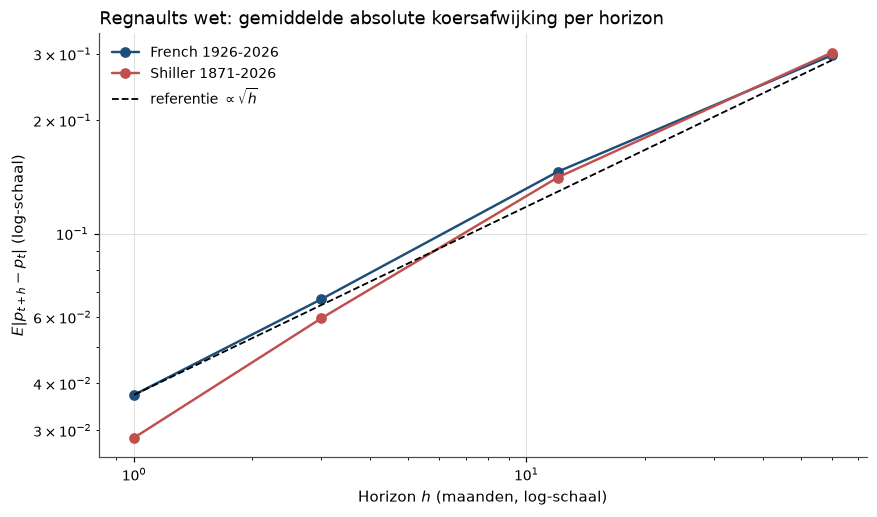

In [11]:
fig, ax = plt.subplots()
for i, (name, block) in enumerate(regnault.groupby(level="reeks")):
    h = block.index.get_level_values("h").to_numpy(float)
    ax.plot(h, block[MAD], "o-", color=hap.plotting.COLORS[i], label=name)
reference = regnault.loc["French 1926-2026", MAD].iloc[0] * np.sqrt([1, 3, 12, 60])
ax.plot([1, 3, 12, 60], reference, ls="--", color="black", lw=1.2,
        label=r"referentie $\propto\sqrt{h}$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Regnaults wet: gemiddelde absolute koersafwijking per horizon")
ax.set_xlabel("Horizon $h$ (maanden, log-schaal)")
ax.set_ylabel("$E|p_{t+h} - p_t|$ (log-schaal)")
ax.legend()
plt.show()

:::{figure} #cel-bachelier-regnault
:label: fig-bachelier-regnault
:width: 90%

Op dubbellogaritmische schaal is Regnaults wet een rechte lijn met helling
$\tfrac12$. Beide reeksen volgen die lijn van één maand tot vijf jaar. De lichte
knik bij de kortste horizon in de Shiller-reeks komt van de maandmiddeling in
zijn prijsreeks, niet van de markt.
:::

```{admonition} Replicatie
:class: seealso

**Bron.** Maurice Kendall, *The Analysis of Economic Time-Series, Part I:
Prices*, JRSS-A 1953 {cite}`Kendall1953`. Andrew Lo en Craig MacKinlay, *Stock
Market Prices Do Not Follow Random Walks*, Review of Financial Studies 1988
{cite}`LoMacKinlay1988`.

**Wat.** Kendalls eerste autocorrelaties van wekelijkse Britse
industrie-indices. Lo en MacKinlay, tabel 1a (variance ratios van hun
waardegewogen marktindex over 1216 weken) en tabel 2 (per grootte-kwintiel).

**Data hier.** De dagelijkse marktfactor van French, opgeteld tot
weekrendementen, en de maandelijkse kwintielportefeuilles op marktwaarde.

**Verschil met het origineel.** Kendall had Britse sectorindices, wij de
Amerikaanse markt. Lo en MacKinlay hadden wekelijkse, gelijkgewogen kwintielen,
wij maandelijkse, waardegewogen.

**Verwachte afwijking.** Markt-$VR(q)$ binnen 0,05 van het origineel, $z$
rond de twee. Lagere waarden voor Kendall en de kwintielen. Falsifieerbaar: de
rangorde, $VR(2)$ daalt van klein naar groot.
```

De eerste cel berekent, zoals Kendall, de eerste vijf autocorrelaties, nu voor
dag-, week- en maandrendementen van de Amerikaanse markt.

In [12]:
daily = np.log1p(hap_data.market_daily()["Mkt"])
weekly = daily.resample("W-FRI").sum()               # vrijdag op vrijdag
monthly = np.log1p(hap_data.market_monthly()["Mkt"])
frequencies = {"dagelijks": daily, "wekelijks": weekly, "maandelijks": monthly}

kendall_rows = {}
for name, s in frequencies.items():
    row = {"waarnemingen": len(s), "standaardfout bij random walk": 1 / np.sqrt(len(s))}
    for k in range(1, 6):
        row[f"ρ({k})"] = s.autocorr(k)
    kendall_rows[name] = row
kendall = pd.DataFrame(kendall_rows).T
kendall.round(4)

,waarnemingen,standaardfout bij random walk,ρ(1),ρ(2),ρ(3),ρ(4),ρ(5)
dagelijks,26296.0,0.0062,0.0470,-0.0235,0.0009,0.0165,0.0094
wekelijks,5223.0,0.0138,0.0304,0.0633,0.0059,-0.0083,-0.0017
maandelijks,1201.0,0.0289,0.0853,-0.0222,-0.0740,0.0205,0.0690


Kendalls resultaat houdt in orde van grootte stand. Onze eerste
weekautocorrelatie ligt ver onder de ongeveer $0{,}13$ die Kendall gemiddeld
vond {cite}`Kendall1953`. Zijn reeksen waren indices van dun verhandelde Britse aandelen,
en die zijn sterker positief gecorreleerd. Dat Kendall nulcorrelaties vond, is
een misverstand: hij vond positieve waarden, maar te zwak om mee te voorspellen.

De grootste autocorrelatie hier is die van maandrendementen, $0{,}085$. Ze is
significant, maar verklaart maar 0,7%
($0{,}085^2$) van de variantie van het volgende maandrendement. De voorspelling
uit de intuïtie, autocorrelaties van nul, houdt dus bijna stand: niet exact nul,
maar te klein om mee te voorspellen.

De variance ratios berekenen we op drie steekproeven: die van Lo en MacKinlay,
de periode na hun steekproef, en het interbellum van 1928 tot 1938, ongeveer
de tijd van Kendalls reeksen {cite}`Kendall1953`.

In [13]:
def vr_table(series, horizons=(2, 4, 8, 16)):
    """Variance ratios with heteroskedasticity-robust z-statistics."""
    out = {"waarnemingen": len(series)}
    for q in horizons:
        result = hap.variance_ratio(series, q)
        out[f"VR({q})"] = result["vr"]
        out[f"z({q})"] = result["z2"]
    return out


# Lo en MacKinlay: 6 september 1962 t/m 26 december 1985, CRSP, woensdag op woensdag.
# French publiceert geen gelijkgewogen dagreeks; wij hebben alleen de waardegewogen markt.
samples = {
    "1962-09 t/m 1985-12": weekly.loc["1962-09-06":"1985-12-26"],
    "1986-01 t/m heden": weekly.loc["1986-01-01":],
    "interbellum 1928-1938": weekly.loc["1928":"1938"],
}
vr_samples = pd.DataFrame({k: vr_table(v) for k, v in samples.items()}).T
vr_samples.round(3)

,waarnemingen,VR(2),z(2),VR(4),z(4),VR(8),z(8),VR(16),z(16)
1962-09 t/m 1985-12,1216.0,1.066,1.633,1.150,2.000,1.219,1.840,1.211,1.219
1986-01 t/m heden,2118.0,0.950,-1.196,0.965,-0.470,0.934,-0.600,0.871,-0.854
interbellum 1928-1938,574.0,1.085,1.612,1.248,2.461,1.428,2.695,1.507,2.167


Op de steekproef van Lo en MacKinlay, 1216 weken zoals bij hen, liggen alle
vier de ratio's boven één. In de veertig jaar na hun steekproef liggen ze alle
vier onder één, maar geen enkele significant. De afwijking is verdwenen, en een
omgekeerd teken is niet aangetoond. In het
interbellum, elf jaar data, is de afwijking het grootst.

Dezelfde berekening per kwintiel op marktwaarde, over 1962–1985, toetst de
rangorde.

In [14]:
size = hap_data.french("Portfolios_Formed_on_ME", "monthly").loc["1962-09":"1985-12"]
quintiles = ["Lo 20", "Qnt 2", "Qnt 3", "Qnt 4", "Hi 20"]

size_table = pd.DataFrame(
    {q: vr_table(np.log1p(size[q].dropna()), horizons=(2, 4, 8)) for q in quintiles}
).T
size_table.index = ["1 (kleinst)", "2", "3", "4", "5 (grootst)"]
size_table.round(3)

,waarnemingen,VR(2),z(2),VR(4),z(4),VR(8),z(8)
1 (kleinst),280.0,1.205,3.356,1.306,2.680,1.508,2.774
2,280.0,1.162,2.693,1.200,1.762,1.318,1.734
3,280.0,1.147,2.470,1.178,1.563,1.303,1.647
4,280.0,1.106,1.817,1.115,1.001,1.220,1.166
5 (grootst),280.0,1.016,0.214,0.999,-0.010,1.151,0.701


$VR(2)$ daalt monotoon van 1,205 bij het kleinste naar 1,016 bij het grootste
kwintiel, en hetzelfde
patroon staat in de kolommen voor $q = 4$ en $q = 8$. De tabel hieronder zet onze
waarden naast die van Kendall en van Lo en MacKinlay.

In [15]:
lm_sample = vr_samples.loc["1962-09 t/m 1985-12"]


def compare(original, here, z_original=np.nan, z_here=np.nan):
    """One row of the original-versus-here table."""
    return {"origineel": original, "hier": here, "z origineel": z_original, "z hier": z_here}


# Originelen: Kendall (1953), ongeveer; Lo en MacKinlay tabel 1a en 2.
q1, q3, q5 = "1 (kleinst)", "3", "5 (grootst)"
comparison_lm = pd.DataFrame.from_dict(
    {
        "Kendall: rho(1) week (gemiddelde)": compare(0.13, kendall.loc["wekelijks", "ρ(1)"]),
        "markt: VR(2)": compare(1.08, lm_sample["VR(2)"], 2.33, lm_sample["z(2)"]),
        "markt: VR(4)": compare(1.16, lm_sample["VR(4)"], 2.31, lm_sample["z(4)"]),
        "markt: VR(8)": compare(1.22, lm_sample["VR(8)"], 2.07, lm_sample["z(8)"]),
        "markt: VR(16)": compare(1.22, lm_sample["VR(16)"], 1.38, lm_sample["z(16)"]),
        "kwintiel 1 (kleinst): VR(2)": compare(1.42, size_table.loc[q1, "VR(2)"], 8.81, size_table.loc[q1, "z(2)"]),
        "kwintiel 3: VR(2)": compare(1.28, size_table.loc[q3, "VR(2)"], 7.38, size_table.loc[q3, "z(2)"]),
        "kwintiel 5 (grootst): VR(2)": compare(1.14, size_table.loc[q5, "VR(2)"], 3.82, size_table.loc[q5, "z(2)"]),
    },
    orient="index",
)
comparison_lm.round(3)

,origineel,hier,z origineel,z hier
Kendall: rho(1) week (gemiddelde),0.13,0.030,NaN,NaN
markt: VR(2),1.08,1.066,2.33,1.633
markt: VR(4),1.16,1.150,2.31,2.000
markt: VR(8),1.22,1.219,2.07,1.840
markt: VR(16),1.22,1.211,1.38,1.219
kwintiel 1 (kleinst): VR(2),1.42,1.205,8.81,3.356
kwintiel 3: VR(2),1.28,1.147,7.38,2.470
kwintiel 5 (grootst): VR(2),1.14,1.016,3.82,0.214


**Geslaagd voor de puntschattingen en de rangorde, gedeeltelijk geslaagd voor
de $z$-waarden.** Voor de marktindex liggen alle vier de schattingen binnen 0,02
van de gepubliceerde waarden, met hetzelfde patroon over $q$. De $z$-waarden
liggen met 1,2 tot 2,0 iets onder de verwachte twee, net als bij hen het laagst
bij $q = 16$. De rangorde over de kwintielen, de falsifieerbare
eis, is die van Lo en MacKinlay. De kwintielniveaus liggen tot 0,2 lager: onze
reeksen zijn maandelijks en waardegewogen, en dat middelt de afhankelijkheid weg.
Kendalls autocorrelatie komt, zoals verwacht, lager uit. Zelfs zijn 0,13
verklaart nog geen 2% ($0{,}13^2$) van de variantie van het volgende
weekrendement.

De figuur vat beide tabellen samen. Let links op de ligging ten opzichte van
één vóór en na 1985, en rechts op de daling van klein naar groot.

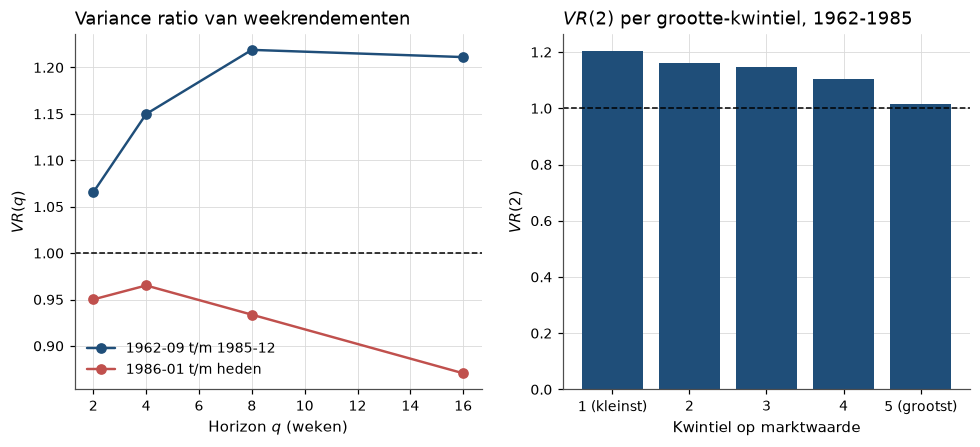

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))

for i, (name, series) in enumerate(list(samples.items())[:2]):
    qs = np.array([2, 4, 8, 16])
    vrs = [hap.variance_ratio(series, q)["vr"] for q in qs]
    axes[0].plot(qs, vrs, "o-", color=hap.plotting.COLORS[i], label=name)
axes[0].axhline(1.0, color="black", lw=1.0, ls="--")
axes[0].set_title("Variance ratio van weekrendementen")
axes[0].set_xlabel("Horizon $q$ (weken)")
axes[0].set_ylabel("$VR(q)$")
axes[0].legend()

axes[1].bar(range(5), size_table["VR(2)"], color=hap.plotting.COLORS[0])
axes[1].axhline(1.0, color="black", lw=1.0, ls="--")
axes[1].set_xticks(range(5), size_table.index)
axes[1].set_title("$VR(2)$ per grootte-kwintiel, 1962-1985")
axes[1].set_xlabel("Kwintiel op marktwaarde")
axes[1].set_ylabel("$VR(2)$")
plt.show()

:::{figure} #cel-bachelier-vr
:label: fig-bachelier-vr
:width: 95%

Links: de variance ratios die Lo en MacKinlay vonden, liggen boven één en lopen
op tot $q = 8$. Na 1985 liggen ze er net onder. Rechts: hoe kleiner de
onderneming, hoe groter de afwijking van de random walk. Beide panelen laten
open of het om een prijsfout ging of om een eigenschap van de handel in kleine
aandelen.
:::

## Wat er brak, en wat daarna kwam

**Wat het model verklaart.** Uit één zin,
opeenvolgende koersveranderingen zijn ongecorreleerd, volgen de $\sqrt{t}$-wet
(helling 0,51 op French-data), de Brownse beweging als limiet, de kans om een
niveau te raken, en een optieformule die voor korte looptijden nauwelijks van
Black-Scholes verschilt. Het verklaart ook waarom beroepsvoorspellers collectief
falen: Cowles vond in 1933 dat adviesdiensten het gemiddeld slechter deden dan
de markt {cite}`Cowles1933`.

**Waar het breekt.** De zwaarste breuk: de random walk zegt iets over
*veranderingen*, niets over het *niveau*. Het is een theorie van de ruis, niet
van de waarde. De tweede breuk is empirisch: variance ratios boven één die dalen
met de grootte van de onderneming. Volgens [](#eq-bachelier-power) is
$VR(2) - 1 = 0{,}205$ van het kleinste kwintiel na
$(1{,}96/0{,}205)^2 \approx 91$ maanden zichtbaar, ongeveer acht jaar. De
week-$\rho_1$ van 0,030 vraagt $(1{,}96/0{,}030)^2 \approx 4270$ weken, en onze
5223 weken volstaan net. Technisch laat aritmetische Brownse beweging negatieve
prijzen toe. Osborne verplaatste haar in 1959 naar de log-prijs
{cite}`Osborne1959`.

**Risico of vergissing?** De variance ratios boven één, hoger bij kleinere
ondernemingen, laten beide lezingen toe. De Chicago-lezing (Fama: prijzen
kloppen): kleine aandelen worden niet elke dag verhandeld, hun laatste koers
loopt achter, en dat maakt indexrendementen vanzelf positief gecorreleerd. De
Yale-lezing (Shiller: prijzen kunnen ernaast zitten): in weinig gevolgde
aandelen past de prijs zich te traag aan. Dat de afwijking na 1985 verdween,
past bij beide: er wordt vaker gehandeld, en er zijn meer analisten. Scheiden
vraagt de handelsfrequentie per aandeel vóór 1985. Die zit in de betaalde
CRSP-databank, niet in de gratis bronnen van deze reeks.

**Wat er daarna kwam.** Voordat iemand kon zeggen of een prijs *fout* was, moest
er een theorie zijn van wat een prijs *hoort* te zijn. John Burr Williams schreef
die in 1938 op: zie [](#01-03-williams-ddm).

## Oefeningen

:::{exercise}
:label: ex-bachelier-instap

**Instap: een scheve munt.** Neem het toy-voorbeeld, maar laat elke stap met
kans 0,6 omhoog gaan en met kans 0,4 omlaag.

1. Bereken $\E[S_4]$ en $\Var(S_4)$ met de hand.
2. Groeit de spreiding van de wandeling nog met de wortel van het aantal stappen?
   Wat betekent dat voor de keuze in de replicatie om veranderingen eerst van hun
   gemiddelde te ontdoen?
:::

:::{solution} ex-bachelier-instap
:class: dropdown

**(1)** Eén stap heeft verwachting $0{,}6 - 0{,}4 = 0{,}2$ en variantie
$1 - 0{,}2^2 = 0{,}96$. Bij onafhankelijke stappen tellen beide op:
$\E[S_4] = 0{,}8$ en $\Var(S_4) = 3{,}84$. De code weegt de zestien paden van
het toy-voorbeeld met hun nieuwe kansen.

In [17]:
prob_up = 0.6
path_prob = np.prod(np.where(paths == 1, prob_up, 1 - prob_up), axis=1)   # kans per pad
mean_skewed = path_prob @ final
var_skewed = path_prob @ (final - mean_skewed) ** 2

pd.DataFrame(
    {"met de hand": [0.8, 3.84], "code": [mean_skewed, var_skewed]},
    index=["E[S_4]", "Var(S_4)"],
).round(4)

,met de hand,code
E[S_4],0.80,0.80
Var(S_4),3.84,3.84


**(2)** De variantie groeit nog steeds lineair, als $0{,}96\,n$, dus de spreiding
rond het verwachte pad groeit met $\sqrt{n}$. Het verwachte pad zelf loopt
lineair weg, als $0{,}2\,n$. Vanaf ongeveer 24 stappen is de drift groter dan de
spreiding ($0{,}2n > \sqrt{0{,}96n}$). Zonder aftrek van het gemiddelde trekt de
drift de geschatte helling naar één.

Wat dit leert: de $\sqrt{t}$-wet gaat over de spreiding rond de drift, en wie
haar toetst, moet de drift eerst verwijderen.
:::

:::{exercise}
:label: ex-bachelier-1

**De variance ratio van een AR(1).** Laat $r_t = \rho\,r_{t-1} + e_t$ met
$|\rho| < 1$ en $e_t$ witte ruis.

1. Toon aan dat $\rho_j = \rho^{\,j}$ en leid met [](#eq-bachelier-vr-rho) een
   gesloten uitdrukking af voor $VR(q)$.
2. Bereken $VR(2)$, $VR(4)$, $VR(8)$ en $VR(16)$ voor $\rho = 0{,}10$, en bepaal
   $\lim_{q \to \infty} VR(q)$.
3. Schat de vier ratio's op één gesimuleerd pad van 1216 weken. Bij welke $q$ is
   de $z$-waarde het grootst, en waarom?
:::

:::{solution} ex-bachelier-1
:class: dropdown

**(1)** Voor een AR(1) is $\Cov(r_t, r_{t-j}) = \rho^{\,j}\sigma_r^2$, dus
$\rho_j = \rho^{\,j}$. Invullen in [](#eq-bachelier-vr-rho) en de meetkundige
reeksen optellen geeft

$$
VR(q) = 1 + \frac{2\rho}{1-\rho}
        \left[1 - \frac{1-\rho^{\,q}}{q\,(1-\rho)}\right].
$$

Voor $q \to \infty$ verdwijnt de tweede term en blijft
$VR(\infty) = (1+\rho)/(1-\rho) = 1{,}1/0{,}9 \approx 1{,}222$ over.

**(2) en (3)** De cel rekent de theoretische waarden uit en schat ze op één
gesimuleerd pad van 1216 weken.

In [18]:
rho_ex = 0.10


def vr_ar1(rho, q):
    """Population variance ratio of an AR(1) at horizon q."""
    j = np.arange(1, q)
    return 1 + 2 * np.sum((1 - j / q) * rho**j)


path = pd.Series(ar1_paths(rho_ex, 1, 1216)[0])
rows = []
for q in (2, 4, 8, 16):
    result = hap.variance_ratio(path, q)
    rows.append({"q": q, "VR theoretisch": vr_ar1(rho_ex, q),
                 "VR geschat": result["vr"], "z": result["z2"]})

pd.DataFrame(rows).set_index("q").round(4)

,VR theoretisch,VR geschat,z
q,,,
2,1.1000,1.1306,4.5063
4,1.1605,1.2138,3.9533
8,1.1914,1.3042,3.5892
16,1.2068,1.4151,3.2934


De theoretische waarden stijgen met sterk afnemende opbrengst naar 1,222. In dit
ene pad (een andere startwaarde van de toevalsgenerator geeft andere getallen)
liggen de schattingen erboven, tot 1,42 bij $q = 16$. De grootste $z$-waarde
valt bij de kleinste horizon: 4,51 bij $q = 2$ tegen 3,29 bij $q = 16$. De
standaardfout van $VR(q)$ groeit ongeveer met $\sqrt{q}$, terwijl $VR(q) - 1$ na
$q = 4$ nauwelijks nog toeneemt.

Wat dit leert: tegen een AR(1) is de kortste horizon de scherpste toets, omdat
het signaal daar al vrijwel volledig is en de ruis het kleinst.
:::

:::{exercise}
:label: ex-bachelier-3

**De replicatie uitgebreid: is de afwijking verdwenen?** Lo en MacKinlay
publiceerden in 1988 op data tot eind 1985.

1. Herhaal de variance-ratio-tabel voor de grootte-kwintielen op de periode
   1986-01 tot heden. Blijft de rangorde bestaan?
2. Bereken per kwintiel het verschil in $VR(2)$ tussen de twee periodes. Hoe
   groot is dat verschil vergeleken met de standaardfout?
3. De anomalie is weggearbitreerd, of de handel zelf is veranderd. Welke meting
   zou de twee verklaringen kunnen scheiden, en hebben wij die?
:::

:::{solution} ex-bachelier-3
:class: dropdown

**(1)** De cel herhaalt de kwintieltabel vanaf 1986.

In [19]:
size_late = hap_data.french("Portfolios_Formed_on_ME", "monthly").loc["1986-01":]
late_table = pd.DataFrame(
    {q: vr_table(np.log1p(size_late[q].dropna()), horizons=(2, 4, 8))
     for q in quintiles}
).T
late_table.index = size_table.index
late_table.round(3)

,waarnemingen,VR(2),z(2),VR(4),z(4),VR(8),z(8)
1 (kleinst),487.0,1.143,2.501,1.184,1.750,1.078,0.491
2,487.0,1.066,1.143,1.017,0.170,0.853,-0.968
3,487.0,1.053,0.882,1.008,0.077,0.886,-0.740
4,487.0,1.049,0.763,1.013,0.115,0.939,-0.375
5 (grootst),487.0,1.017,0.279,0.983,-0.156,1.015,0.095


De rangorde blijft bestaan, van 1,143 bij het kleinste naar 1,017 bij het
grootste kwintiel, maar het profiel is naar beneden geschoven. Alleen het
kleinste kwintiel is met $z = 2{,}50$ nog significant, en bij $q = 8$ is het
patroon verdwenen.

**(2)** De volgende cel zet de twee periodes naast elkaar, met de standaardfout
$1/\sqrt{T}$ per periode.

In [20]:
comparison = pd.DataFrame(
    {
        "VR(2) 1962-1985": size_table["VR(2)"],
        "VR(2) 1986-heden": late_table["VR(2)"],
        "SE 1962-1985": 1 / np.sqrt(size_table["waarnemingen"].astype(float)),
        "SE 1986-heden": 1 / np.sqrt(late_table["waarnemingen"].astype(float)),
    }
)
comparison["verschil"] = comparison["VR(2) 1962-1985"] - comparison["VR(2) 1986-heden"]
comparison["t van het verschil"] = comparison["verschil"] / np.sqrt(
    comparison["SE 1962-1985"] ** 2 + comparison["SE 1986-heden"] ** 2
)
comparison.round(3)

,VR(2) 1962-1985,VR(2) 1986-heden,SE 1962-1985,SE 1986-heden,verschil,t van het verschil
1 (kleinst),1.205,1.143,0.06,0.045,0.062,0.828
2,1.162,1.066,0.06,0.045,0.096,1.284
3,1.147,1.053,0.06,0.045,0.094,1.254
4,1.106,1.049,0.06,0.045,0.057,0.757
5 (grootst),1.016,1.017,0.06,0.045,-0.001,-0.013


Geen van de vijf verschillen haalt twee standaardfouten. De hoogste $t$-waarde
is 1,28. Met 280 en 487 maandwaarnemingen is de standaardfout van het verschil
$\sqrt{1/280 + 1/487} \approx 0{,}075$, en de verschuiving voor de vier
kleinste kwintielen is 0,06 tot 0,10. Dat is [](#eq-bachelier-power) van de
andere kant bekeken: de afwijking lijkt verdwenen, maar het verschil is
statistisch niet van nul te onderscheiden.

**(3)** Beide verklaringen voorspellen dat de afwijking sinds 1985 kleiner
werd, zoals in "Risico of vergissing?". De meting die ze scheidt, de
handelsfrequentie per aandeel vóór 1985, zit in CRSP (de betaalde databank met
Amerikaanse aandelenkoersen sinds 1926), en die hebben wij niet.

Wat dit leert: dat een anomalie na publicatie verdwijnt, is met één reeks niet
te bewijzen, en waarom ze verdween, is met de gratis data niet te beslissen.
:::

<!-- Referenties verschijnen automatisch onderaan de pagina. -->